<a href="https://colab.research.google.com/github/VictorHugoTesti/-am-t4-s1a2026/blob/main/prova_21_Victor_Testi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prova 21: IBAMA | Autuações e Multas Ambientais

**Consumo:** Base com valores monetários em formato de string com vírgulas (ex: "1.500,00").

**Alvo (4Y4):** Multa_Grave se o valor da multa ultrapassar a mediana da base.

**Desafio:** Conversão robusta de strings financeiras para float antes do StandardScaler.

Nome: Victor Hugo Malipense Testi

# Pipeline | Carregamento [Fase 1 - base_ibama]

## Bibliotecas Python

In [1059]:
!pip -q install plotly
!pip -q install yellowbrick

In [1060]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Importar Dados do Drive

In [1061]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importar DataFrame [base_ibama]

In [1062]:
base_ibama = pd.read_csv('/content/drive/MyDrive/Aprendizagem de Maquina/prova - ML/volumeJulgamentoAI.csv', sep=';')

In [1063]:
base_ibama

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Número AI,Nome ou Razão Social,CPF/CNPJ,UF,Município,Status Débito,Decisão Administrativa,Tipo Auto,Tipo de Infração,Enquadramento,Data Julgamento Principal,Data Julgamento Recurso,Data Auto,Valor do Auto,Moeda,Valor Pago,Data Pagamento,Última Atualização Relatório
0,0QRNTRF2 -,RONALDO DA COSTA CUNHA,792.049.372-20,AC,CRUZEIRO DO SUL,Quitado. Baixa automática,NaN,Multa,Fauna,"Lei 9605/98 - Artigo 72, Lei 9605/98 - Artigo ...",NaN,23/02/2026,26/01/2026,500,Real,"353,5",20/02/2026,19/04/2026 21:56
1,0YIWNUKS -,JUZALDO RUFINO MOTA,411.867.022-49,AC,RIO BRANCO,Quitado. Baixa automática,NaN,Multa,Flora,Decreto 6514/2008 - Artigo 57,NaN,25/09/2025,03/04/2023,"1,000",Real,707,14/04/2023,19/04/2026 21:56
2,11175 - D,PAULO COUTO CABRAL,363.359.919-34,AC,RIO BRANCO,Quitado. Baixa automática,NaN,Multa,Flora,NaN,30/09/1998,NaN,31/08/1998,"1,240",Real,305,02/12/1998,19/04/2026 21:56
3,112481 - D,OURO BRANCO MADEIRAS IMP. E EXP. LTDA.,00.525.034/0001-08,AC,CAPIXABA,Quitado. Baixa automática,NaN,Multa,Flora,NaN,22/08/2003,NaN,20/01/2003,"5,588",Real,"3,854,3",11/09/2003,19/04/2026 21:56
4,11255 - D,SINÉZIO JOSÉ FALCÃO,139.287.402-53,AC,ACRELANDIA,Parcelado pela 1ª vez,NaN,Multa,Flora,NaN,30/09/1998,NaN,04/09/1998,500,Real,"73,4",22/03/2000,19/04/2026 21:56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2912,WIZBMOWS -,MARIA ADÉLIA FALTZ BREDA,015.205.617-33,AC,ACRELANDIA,Quitado. Baixa automática,NaN,Multa,Flora,"Lei 9605/98 - Artigo 72, Lei 9605/98 - Artigo ...",NaN,NaN,12/08/2025,"30,000",Real,"21,000",26/08/2025,19/04/2026 21:56
2913,XFSQE06B -,VICTOR FAVORETO MOURA HYPOLITTO,469.999.878-07,AC,RIO BRANCO,Quitado. Baixa automática,NaN,Multa,Fauna,"Lei 9605/98 - Artigo 72, Decreto 6514/2008 - A...",NaN,23/09/2024,14/06/2024,500,Real,"359,7",23/09/2024,19/04/2026 21:56
2914,YA6X8PV7 -,CELIO FERREIRA FURTADO,860.048.912-15,AC,SENA MADUREIRA,Quitado. Baixa automática,NaN,Multa,Fauna,"Lei 9605/98 - Artigo 70, Decreto 6514/2008 - A...",NaN,NaN,12/09/2022,"5,000",Real,"4,045,3",15/12/2023,19/04/2026 21:56
2915,ZE5A8NQQ -,FRANCISCO SERGIO FRANCO DE SOUZA,612.722.992-87,AC,BRASILEIA,Quitado. Baixa automática,NaN,Multa,Cadastro Técnico Federal,"Lei 9605/98 - Artigo 70, Decreto 6514/2008 - A...",NaN,NaN,02/09/2023,"1,000",Real,"720,8",22/11/2023,19/04/2026 21:56


# Pipeline | Detecção de Anomalias e Tratamento dos Dados [Fase 2 - base_ibama]

## Convertendo Coluna "Valor do Auto" [String -> Float]

In [1064]:
pd.options.display.float_format = '{:,.2f}'.format

base_ibama['Valor do Auto'] = pd.to_numeric(
    base_ibama['Valor do Auto']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True),
    errors='coerce'
)

In [1065]:
base_ibama['Valor do Auto'].describe()

,Valor do Auto
count,"2,917.00"
mean,"7,254.41"
std,"25,357.33"
min,50.00
25%,500.00
50%,"1,000.00"
75%,"3,500.00"
max,"595,500.00"


In [1066]:
base_ibama['Valor do Auto']

,Valor do Auto
0,500
1,1000
2,1240
3,5588
4,500
...,...
2912,30000
2913,500
2914,5000
2915,1000


## Detecção de Anomalias

Possiveis Nulidades - (Dados Nulos em Base) | Resultante: Nulo

In [1067]:
base_ibama.isnull().sum()

,0
Número AI,0
Nome ou Razão Social,0
CPF/CNPJ,30
UF,0
Município,0
Status Débito,0
Decisão Administrativa,2659
Tipo Auto,0
Tipo de Infração,0
Enquadramento,1684


Possiveis Valores de Multas Negativas - (Incongruencias ou Impossibilidades) | Resultante: Nulos

In [1068]:
base_ibama.loc[base_ibama['Valor do Auto'] < 0]

,Número AI,Nome ou Razão Social,CPF/CNPJ,UF,Município,Status Débito,Decisão Administrativa,Tipo Auto,Tipo de Infração,Enquadramento,Data Julgamento Principal,Data Julgamento Recurso,Data Auto,Valor do Auto,Moeda,Valor Pago,Data Pagamento,Última Atualização Relatório


Possiveis Valores acima do Valor Máximo Estipulado por Lei - (Incongruencias ou Impossibilidades) | Resultante:Nulos

In [1069]:
base_ibama.loc[base_ibama['Valor do Auto'] > 50000000]

,Número AI,Nome ou Razão Social,CPF/CNPJ,UF,Município,Status Débito,Decisão Administrativa,Tipo Auto,Tipo de Infração,Enquadramento,Data Julgamento Principal,Data Julgamento Recurso,Data Auto,Valor do Auto,Moeda,Valor Pago,Data Pagamento,Última Atualização Relatório


Possiveis Valores abaixo do Valor Minímo Estipulado por Lei - (Incongruencias ou Impossibilidades) | Resultante:Nulos

In [1070]:
base_ibama.loc[base_ibama['Valor do Auto'] < 50]

,Número AI,Nome ou Razão Social,CPF/CNPJ,UF,Município,Status Débito,Decisão Administrativa,Tipo Auto,Tipo de Infração,Enquadramento,Data Julgamento Principal,Data Julgamento Recurso,Data Auto,Valor do Auto,Moeda,Valor Pago,Data Pagamento,Última Atualização Relatório


## Tratamento e Padronização Anomalias

In [1071]:
base_ibama = base_ibama.dropna(subset=['Enquadramento'])

In [1072]:
base_ibama.isnull().sum()

,0
Número AI,0
Nome ou Razão Social,0
CPF/CNPJ,0
UF,0
Município,0
Status Débito,0
Decisão Administrativa,1080
Tipo Auto,0
Tipo de Infração,0
Enquadramento,0


# Pipeline | Visualização de Dados [Fase 3 - base_ibama]

Histograma

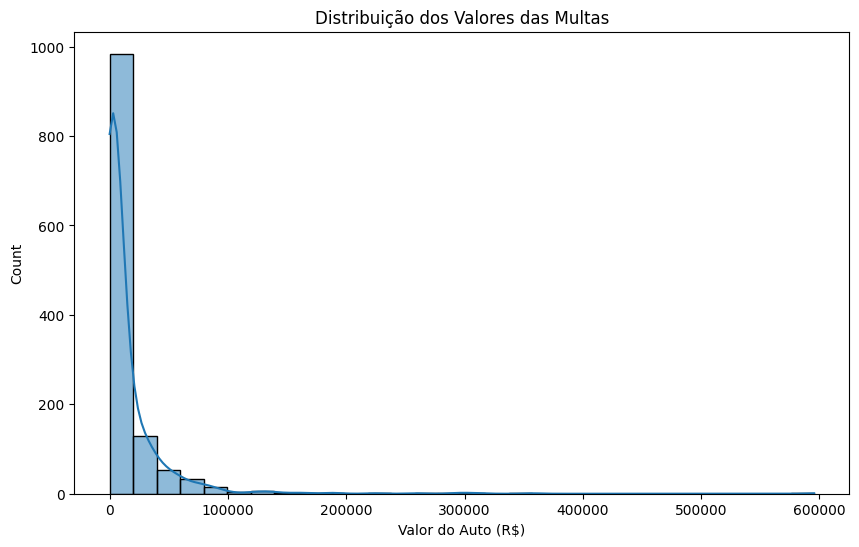

In [1073]:
plt.figure(figsize=(10, 6))
sns.histplot(base_ibama['Valor do Auto'], bins=30, kde=True)
plt.title('Distribuição dos Valores das Multas')
plt.xlabel('Valor do Auto (R$)')
plt.show()

Gráfico de Contagem

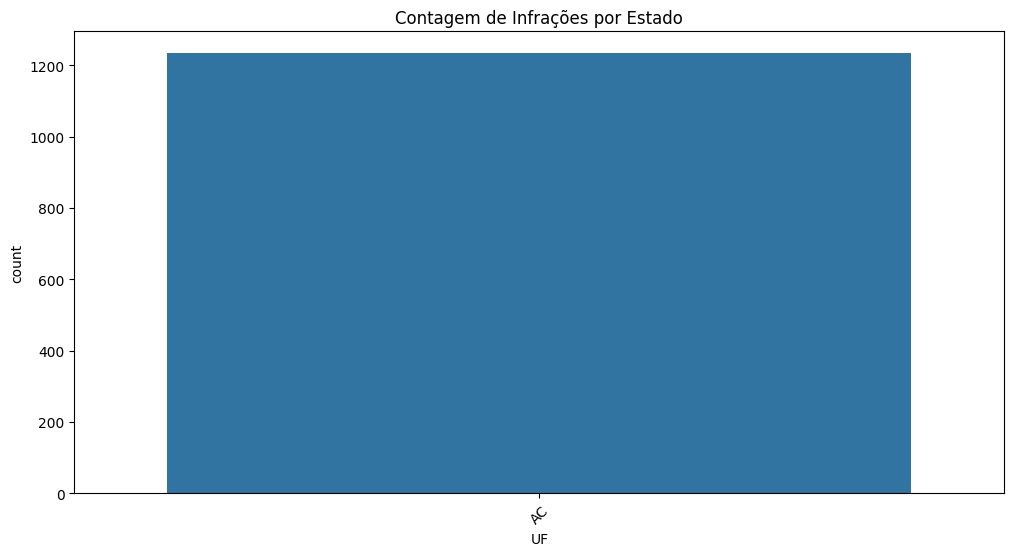

In [1074]:
plt.figure(figsize=(12, 6))
sns.countplot(data=base_ibama, x='UF')
plt.title('Contagem de Infrações por Estado')
plt.xticks(rotation=45)
plt.show()

# Pipeline | Laborização [Fase 4 - base_ibama]

## Cálculo de mediana e Desvio Padrão

In [1075]:
mediana = base_ibama['Valor do Auto'].median()

In [1076]:
mediana

3000.0

In [1077]:
desvio = base_ibama['Valor do Auto'].std()

In [1078]:
desvio

33839.16108412572

## Alvos de Aprendizagem [Target - Multa_Grave]

In [1079]:
base_ibama['Multa_Grave'] = base_ibama['Valor do Auto'].apply(lambda x: 1 if x > mediana else 0)

/tmp/ipykernel_3327/235614347.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  base_ibama['Multa_Grave'] = base_ibama['Valor do Auto'].apply(lambda x: 1 if x > mediana else 0)


In [1080]:
base_ibama['Multa_Grave'].value_counts()

,count
Multa_Grave,
0,633
1,600


# Pipeline | Normalização e Divisão [Fase 5 - base_ibama]

In [1081]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import numpy as np

## Eixos de Aprendizagem

In [1082]:
base_ibama.columns

Index(['Número AI', 'Nome ou Razão Social', 'CPF/CNPJ', 'UF', 'Município',
       'Status Débito', 'Decisão Administrativa', 'Tipo Auto',
       'Tipo de Infração', 'Enquadramento', 'Data Julgamento Principal',
       'Data Julgamento Recurso', 'Data Auto', 'Valor do Auto', 'Moeda',
       'Valor Pago', 'Data Pagamento', 'Última Atualização Relatório',
       'Multa_Grave'],
      dtype='object')

In [1083]:
Y_ibama = base_ibama['Multa_Grave'].values

In [1084]:
Y_ibama

array([0, 0, 0, ..., 1, 0, 0])

In [1085]:
X_ibama = base_ibama[['UF', 'Tipo de Infração', 'Enquadramento', 'Município', 'Tipo Auto']].values

In [1086]:
X_ibama

array([['AC', 'Fauna',
        'Lei 9605/98 - Artigo 72, Lei 9605/98 - Artigo 70, Decreto 6514/2008 - Artigo 3, Decreto 6514/2008 - Artigo 24',
        'CRUZEIRO DO SUL', 'Multa'],
       ['AC', 'Flora', 'Decreto 6514/2008 - Artigo 57', 'RIO BRANCO',
        'Multa'],
       ['AC', 'Fauna',
        'Lei 9605/98 - Artigo 72, Lei 9605/98 - Artigo 70, Decreto 6514/2008 - Artigo 3, Decreto 6514/2008 - Artigo 24',
        'SENADOR GUIOMARD', 'Multa'],
       ...,
       ['AC', 'Fauna',
        'Lei 9605/98 - Artigo 70, Decreto 6514/2008 - Artigo 3, Decreto 6514/2008 - Artigo 24',
        'SENA MADUREIRA', 'Multa'],
       ['AC', 'Cadastro Técnico Federal',
        'Lei 9605/98 - Artigo 70, Decreto 6514/2008 - Artigo 3, Decreto 6514/2008 - Artigo 57',
        'BRASILEIA', 'Multa'],
       ['AC', 'Controle ambiental', 'Decreto 6514/2008 - Artigo 68',
        'RIO BRANCO', 'Multa']], dtype=object)

## LabelEncoder

In [1087]:
# for i in range(5):
#     X_ibama[:, i] = LabelEncoder().fit_transform(X_ibama[:, i])

In [1088]:
label_encoder_uf = LabelEncoder()
label_encoder_tipo_infracao = LabelEncoder()
label_encoder_enquadramento = LabelEncoder()
label_encoder_municipio = LabelEncoder()
label_encoder_tipo_auto = LabelEncoder()

In [1089]:
X_ibama[:, 0] = label_encoder_uf.fit_transform(X_ibama[:, 0])
X_ibama[:, 1] = label_encoder_tipo_infracao.fit_transform(X_ibama[:, 1])
X_ibama[:, 2] = label_encoder_enquadramento.fit_transform(X_ibama[:, 2])
X_ibama[:, 3] = label_encoder_municipio.fit_transform(X_ibama[:, 3])
X_ibama[:, 4] = label_encoder_tipo_auto.fit_transform(X_ibama[:, 4])

## OneHotEncoder

In [1090]:
onehot_ibama = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(), [0, 1, 2, 3, 4])
], remainder='passthrough')

# onehot = ColumnTransformer(transformers=[
#     ('onehot', OneHotEncoder(), [0, 4])
# ], remainder='passthrough')

In [1091]:
X_ibama = onehot_ibama.fit_transform(X_ibama).toarray()

In [1092]:
X_ibama = np.array(X_ibama)

## StandardScaler

In [1093]:
scaler = StandardScaler()
X_ibama =  scaler.fit_transform(X_ibama)

## Divisão da Base para Treino e Teste [base_ibama]

In [1094]:
X_treino, X_teste, Y_treino, Y_teste = train_test_split(X_ibama, Y_ibama, test_size=0.15, random_state=42)

# Pipeline | Ingestão Bayesiana e Avaliação [Fase 6 - base_ibama]

In [1095]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Treinamento - GaussianNB()

In [1096]:
modelo_nb = GaussianNB()
modelo_nb.fit(X_treino, Y_treino)

GaussianNB()

## Avaliação - Acuracia e Matriz de Confusão

In [1097]:
previsoes = modelo_nb.predict(X_teste)

In [1098]:
accuracy_score(Y_teste, previsoes)

0.572972972972973

In [1099]:
confusion_matrix(Y_teste, previsoes)

array([[27, 74],
       [ 5, 79]])

In [1100]:
print("\nRelatório Final:\n", classification_report(Y_teste, previsoes))


Relatório Final:
               precision    recall  f1-score   support

           0       0.84      0.27      0.41       101
           1       0.52      0.94      0.67        84

    accuracy                           0.57       185
   macro avg       0.68      0.60      0.54       185
weighted avg       0.70      0.57      0.52       185



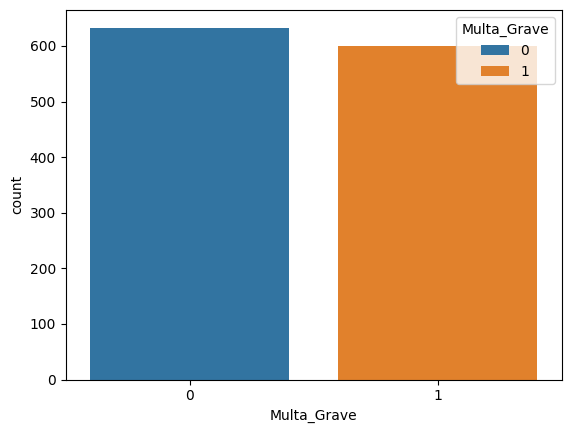

In [1101]:
sns.countplot(
    x = base_ibama['Multa_Grave'],
    hue = base_ibama['Multa_Grave'],
);